In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")
print(df) 

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [2]:
print(f"Mean Age : {df['age'].mean()}")
print(f"Mean BMI : {df['bmi'].mean()}")
print(f"Mean Children : {df['children'].mean()}")
print(f"Mean Charges : {df['charges'].mean()}")

print(f"Median Age : {df['age'].median()}")
print(f"Median BMI : {df['bmi'].median()}")
print(f"Median Children : {df['children'].median()}")
print(f"Median Charges : {df['charges'].median()}")

print(f"Standard Deviation of Age : {df['age'].std()}")
print(f"Standard Deviation of BMI : {df['bmi'].std()}")
print(f"Standard Deviation of Children : {df['children'].std()}")
print(f"Standard Deviation of Charges : {df['charges'].std()}",end="\n")

print(f"IQR of Age : {df['age'].quantile(0.75)-df['age'].quantile(0.25)}")
print(f"IQR of BMI : {df['bmi'].quantile(0.75)-df['bmi'].quantile(0.25)}")
print(f"IQR of Children : {df['children'].quantile(0.75)-df['children'].quantile(0.25)}")
print(f"IQR of Charges : {df['charges'].quantile(0.75)-df['charges'].quantile(0.25)}",end="\n")


print(f"Skewness of Age : {df['age'].skew()}")
print(f"Skewness of BMI : {df['bmi'].skew()}")
print(f"Skewness of Children : {df['children'].skew()}")
print(f"Skewness of Charges : {df['charges'].skew()}")

print(f"Kurtosis of Age : {df['age'].kurtosis()}")
print(f"Kurtosis of BMI : {df['bmi'].kurtosis()}")
print(f"Kurtosis of Children : {df['children'].kurtosis()}")
print(f"Kurtosis of Charges : {df['charges'].kurtosis()}")



Mean Age : 39.20702541106129
Mean BMI : 30.66339686098655
Mean Children : 1.0949177877429
Mean Charges : 13270.422265141257
Median Age : 39.0
Median BMI : 30.4
Median Children : 1.0
Median Charges : 9382.033
Standard Deviation of Age : 14.049960379216154
Standard Deviation of BMI : 6.098186911679014
Standard Deviation of Children : 1.205492739781914
Standard Deviation of Charges : 12110.011236694001
IQR of Age : 24.0
IQR of BMI : 8.3975
IQR of Children : 2.0
IQR of Charges : 11899.625365
Skewness of Age : 0.05567251565299186
Skewness of BMI : 0.2840471105987448
Skewness of Children : 0.9383804401702414
Skewness of Charges : 1.5158796580240388
Kurtosis of Age : -1.2450876526418673
Kurtosis of BMI : -0.05073153135467834
Kurtosis of Children : 0.2024541467168901
Kurtosis of Charges : 1.6062986532967907


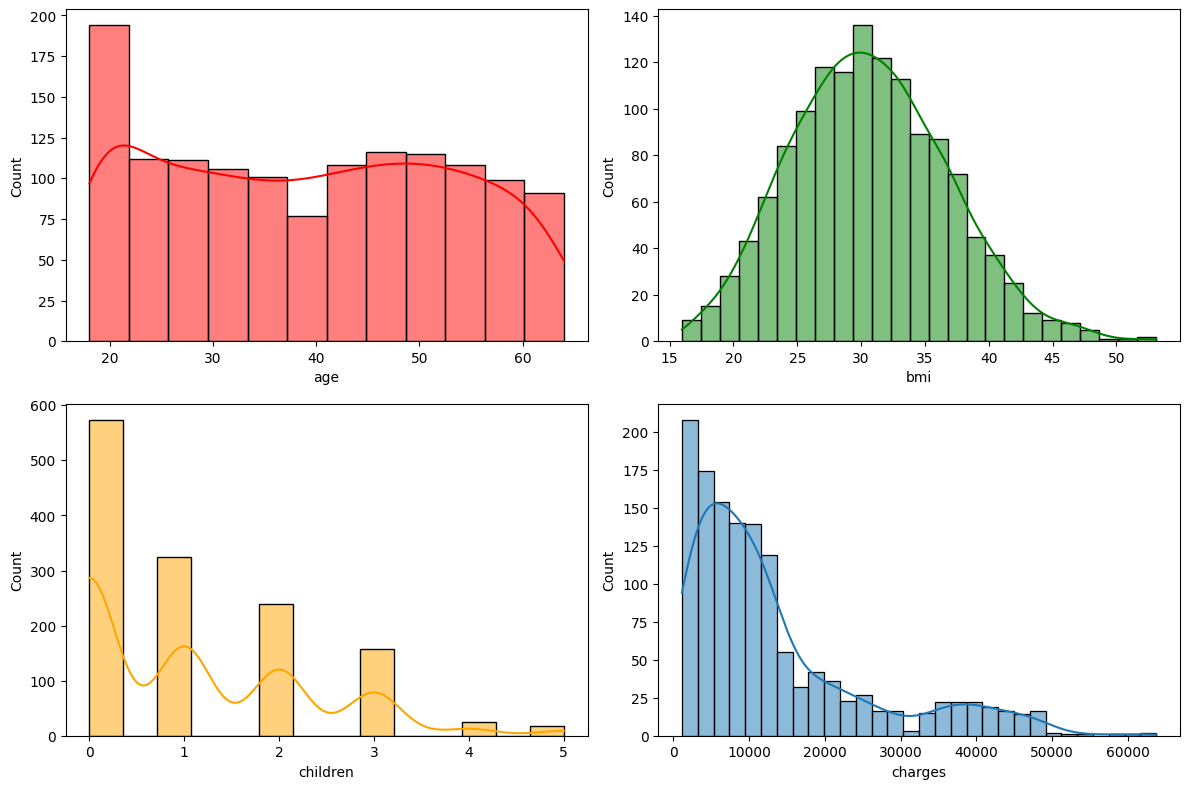

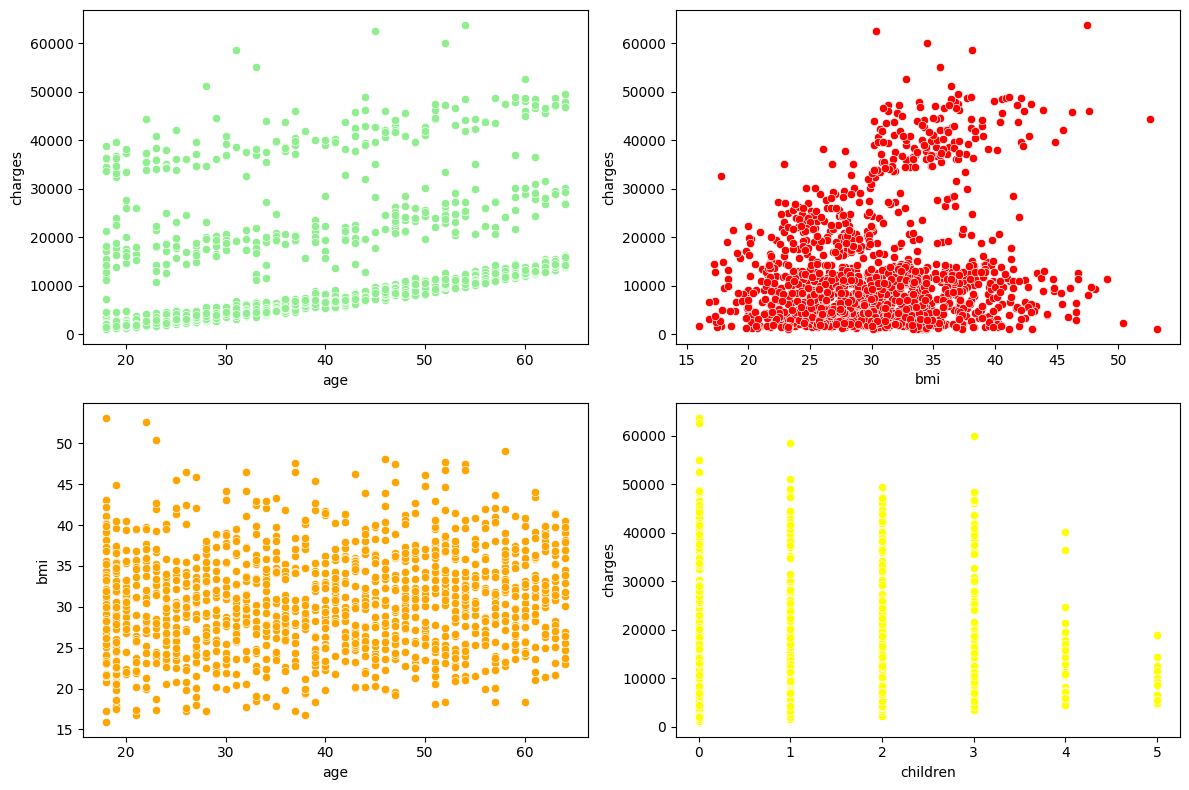

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['age'], kde=True, ax=ax[0,0],color="red")
sns.histplot(df['bmi'], kde=True, ax=ax[0,1],color="green")
sns.histplot(df['children'], kde=True, ax=ax[1,0],color="orange")
sns.histplot(df['charges'], kde=True, ax=ax[1,1])

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.scatterplot(x=df['age'], y=df['charges'], color="lightgreen", ax=ax[0,0])
sns.scatterplot(x=df['bmi'], y=df['charges'], color="red", ax=ax[0,1])
sns.scatterplot(x=df['age'], y=df['bmi'], color="orange", ax=ax[1,0])
sns.scatterplot(x=df['children'], y=df['charges'], color="yellow", ax=ax[1,1])

plt.tight_layout()
plt.show()

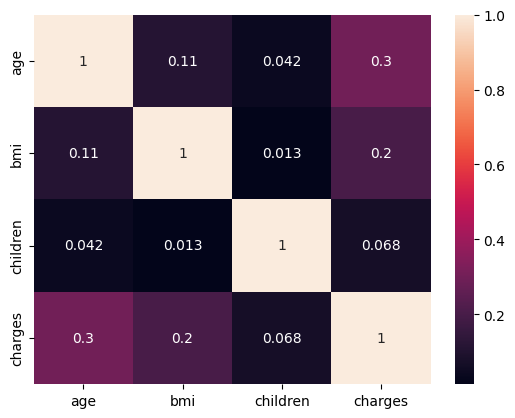

In [4]:
sns.heatmap(df[['age', 'bmi', 'children', 'charges']].corr(), annot=True)
plt.show()

In [9]:
from scipy import stats

alpha = 0.05

smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']

stat_smoke, p_smoke = stats.shapiro(smokers)
stat_nonsmoke, p_nonsmoke = stats.shapiro(non_smokers)
print(f"Shapiro-Wilk (Smokers): stat={stat_smoke:.4f}, p={p_smoke:.4e}")
print(f"Shapiro-Wilk (Non-Smokers): stat={stat_nonsmoke:.4f}, p={p_nonsmoke:.4e}")

stat_levene, p_levene = stats.levene(smokers, non_smokers)
print(f"\nLevene's Test: stat={stat_levene:.4f}, p={p_levene:.4e}")

normal = (p_smoke > alpha) and (p_nonsmoke > alpha)
equal_var = p_levene > alpha

if normal:
    test_stat, p_value = stats.ttest_ind(smokers, non_smokers, equal_var=equal_var)
    test_used = "Two-Sample t-test"
else:
    test_stat, p_value = stats.mannwhitneyu(smokers, non_smokers, alternative='two-sided')
    test_used = "Mann-Whitney U test"

print(f"\nTest used: {test_used}")
print(f"Statistic = {test_stat:.4f}, p-value = {p_value:.4e}")

if p_value < alpha:
    print("\nConclusion: Reject H0 -> Charges significantly differ between smokers and non-smokers.")
else:
    print("\nConclusion: Fail to Reject H0 -> No significant difference in charges between smokers and non-smokers.")

Shapiro-Wilk (Smokers): stat=0.9396, p=3.6250e-09
Shapiro-Wilk (Non-Smokers): stat=0.8729, p=1.4459e-28

Levene's Test: stat=332.6135, p=1.5593e-66

Test used: Mann-Whitney U test
Statistic = 284133.0000, p-value = 5.2702e-130

Conclusion: Reject H0 -> Charges significantly differ between smokers and non-smokers.


In [10]:
regions = df['region'].unique()
region_groups = [df[df['region'] == r]['charges'] for r in regions]

anova_stat, anova_p = stats.f_oneway(*region_groups)
print(f"One-Way ANOVA: F-statistic = {anova_stat:.4f}, p-value = {anova_p:.4e}")

if anova_p < alpha:
    print("Conclusion: Reject H0 -> Average charges differ significantly across regions.")
else:
    print("Conclusion: Fail to Reject H0 -> No significant difference in average charges across regions.")

One-Way ANOVA: F-statistic = 2.9696, p-value = 3.0893e-02
Conclusion: Reject H0 -> Average charges differ significantly across regions.


In [11]:
contingency_table = pd.crosstab(df['smoker'], df['region'])
print(contingency_table)

chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Test: stat={chi2_stat:.4f}, dof={dof}, p-value={chi2_p:.4e}")

if chi2_p < alpha:
    print("Conclusion: Reject H0 -> Smoking status is significantly associated with region.")
else:
    print("Conclusion: Fail to Reject H0 -> No significant association between smoking status and region.")

region  northeast  northwest  southeast  southwest
smoker                                            
no            257        267        273        267
yes            67         58         91         58

Chi-Square Test: stat=7.3435, dof=3, p-value=6.1720e-02
Conclusion: Fail to Reject H0 -> No significant association between smoking status and region.


In [13]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera

model = smf.ols(
    formula="charges ~ age + bmi + children + C(smoker) + C(sex) + C(region) + bmi:C(smoker)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     780.0
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:41:35   Log-Likelihood:                -13248.
No. Observations:                1338   AIC:                         2.652e+04
Df Residuals:                    1328   BIC:                         2.657e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -2223

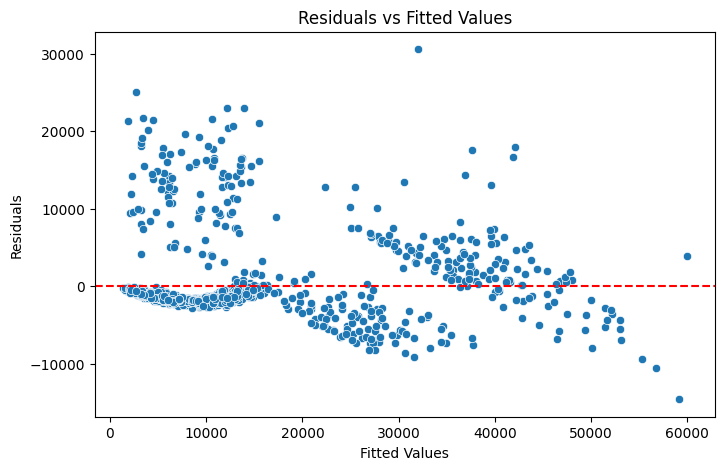

In [14]:
fitted_vals = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

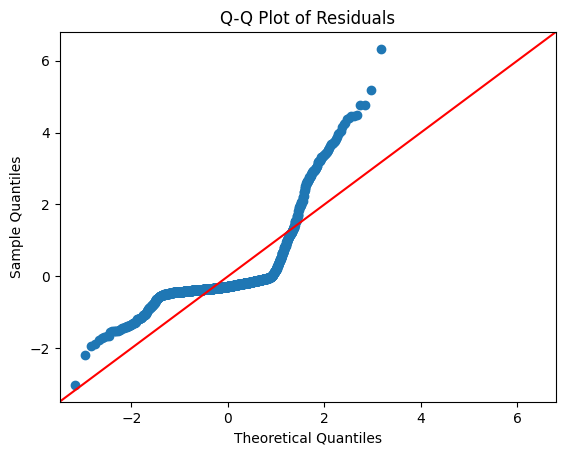

Jarque-Bera Test: stat=4465.2356, p-value=0.0000e+00
Skew=2.5287, Kurtosis=10.3835

Omnibus Test: stat=721.5964, p-value=2.0293e-157


In [15]:
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

jb_stat, jb_p, skew, kurtosis = jarque_bera(residuals)
print(f"Jarque-Bera Test: stat={jb_stat:.4f}, p-value={jb_p:.4e}")
print(f"Skew={skew:.4f}, Kurtosis={kurtosis:.4f}")

omnibus_stat, omnibus_p = stats.normaltest(residuals)
print(f"\nOmnibus Test: stat={omnibus_stat:.4f}, p-value={omnibus_p:.4e}")

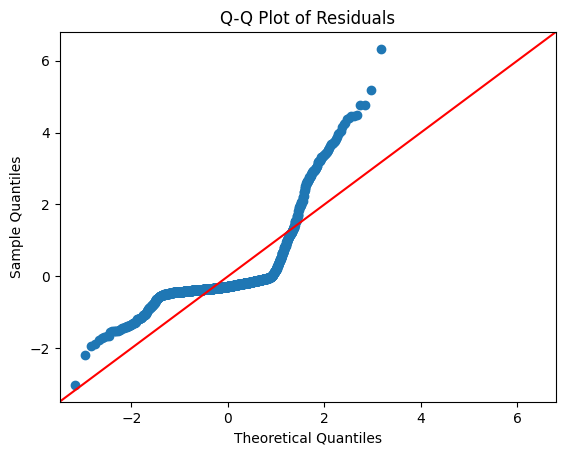

Jarque-Bera Test: stat=4465.2356, p-value=0.0000e+00
Skew=2.5287, Kurtosis=10.3835

Omnibus Test: stat=721.5964, p-value=2.0293e-157


In [16]:
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

jb_stat, jb_p, skew, kurtosis = jarque_bera(residuals)
print(f"Jarque-Bera Test: stat={jb_stat:.4f}, p-value={jb_p:.4e}")
print(f"Skew={skew:.4f}, Kurtosis={kurtosis:.4f}")

omnibus_stat, omnibus_p = stats.normaltest(residuals)
print(f"\nOmnibus Test: stat={omnibus_stat:.4f}, p-value={omnibus_p:.4e}")